# Machine Learning Models for Early Player Retention Prediction

## Objective

This notebook develops and evaluates multiple supervised machine learning models to predict early player retention using behavioural features engineered from the first 24 hours of gameplay.

Three classification algorithms are evaluated:

- Logistic Regression (Baseline Model)
- Random Forest
- XGBoost

The models are compared using multiple evaluation metrics including Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix analysis. The best-performing model will subsequently be used for explainability analysis using SHAP.

In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [26]:
# Load analytical dataset

df = pd.read_csv("../data/player_features_final.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (11080, 31)


,pid,age,gender,country,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,...,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
0,p126,29.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
1,p1317,35.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
2,p1661,18.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
3,p3338,24.0,Female,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
4,p10095,32.0,Female,UK,1,0,1,0.0,1,1,...,2,106.5,155,58.0,58,1.0,0.0,0.0,0.0,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11080 entries, 0 to 11079
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pid                           11080 non-null  object 
 1   age                           10964 non-null  float64
 2   gender                        11018 non-null  object 
 3   country                       10670 non-null  object 
 4   login_count_24h               11080 non-null  int64  
 5   repeat_login_count_24h        11080 non-null  int64  
 6   active_days_24h               11080 non-null  int64  
 7   avg_login_gap_minutes         11080 non-null  float64
 8   jobs_started_24h              11080 non-null  int64  
 9   unique_jobs_started_24h       11080 non-null  int64  
 10  career_jobs_started_24h       11080 non-null  int64  
 11  special_jobs_started_24h      11080 non-null  int64  
 12  freeplay_jobs_started_24h     11080 non-null  int64  
 13  c

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10964.0,28.251186,8.813566,18.0,21.0,27.000000,33.000,118.000000
login_count_24h,11080.0,1.013177,1.142365,0.0,0.0,1.000000,1.000,23.000000
repeat_login_count_24h,11080.0,0.384116,0.886928,0.0,0.0,0.000000,0.000,22.000000
active_days_24h,11080.0,0.728339,0.629645,0.0,0.0,1.000000,1.000,2.000000
avg_login_gap_minutes,11080.0,109.310749,263.815408,0.0,0.0,0.000000,0.000,1424.950000
jobs_started_24h,11080.0,2.409296,4.545791,0.0,0.0,1.000000,3.000,100.000000
unique_jobs_started_24h,11080.0,2.318682,3.970758,0.0,0.0,1.000000,3.000,60.000000
career_jobs_started_24h,11080.0,2.207220,3.793028,0.0,0.0,1.000000,3.000,76.000000
special_jobs_started_24h,11080.0,0.100361,0.477341,0.0,0.0,0.000000,0.000,10.000000
freeplay_jobs_started_24h,11080.0,0.074549,1.139610,0.0,0.0,0.000000,0.000,60.000000


In [29]:
df["retained"].value_counts()

retained
1    5570
0    5510
Name: count, dtype: int64

## Correlation Analysis

Before model development, a correlation analysis was performed to examine relationships among the engineered numerical features.

The objective was to identify potential multicollinearity and better understand the behavioural relationships within the engineered feature set. The correlation analysis serves as an exploratory diagnostic rather than a feature selection criterion, as tree-based machine learning algorithms are generally robust to correlated predictors.

In [30]:
numerical_features = df.select_dtypes(include=["number"])

numerical_features.head()

,age,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,career_jobs_started_24h,special_jobs_started_24h,freeplay_jobs_started_24h,...,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
0,29.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
1,35.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
2,18.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
3,24.0,0,0,0,0.0,0,0,0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
4,32.0,1,0,1,0.0,1,1,1,0,0,...,2,106.5,155,58.0,58,1.0,0.0,0.0,0.0,0


In [31]:
correlation_matrix = numerical_features.corr()

correlation_matrix.head()

,age,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,career_jobs_started_24h,special_jobs_started_24h,freeplay_jobs_started_24h,...,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
age,1.000000,0.078742,0.066081,0.069260,0.044051,0.030446,0.035571,0.039259,-0.010820,0.000142,...,0.037391,0.085556,0.097482,0.064808,0.082355,0.062559,-0.011710,0.002071,-0.008288,0.117064
login_count_24h,0.078742,1.000000,0.917037,0.776848,0.504048,0.457883,0.481036,0.489292,0.213751,0.090487,...,0.543325,0.164361,0.274443,0.141224,0.241731,0.589476,0.112473,0.109377,0.056847,0.315977
repeat_login_count_24h,0.066081,0.917037,1.000000,0.516753,0.475908,0.377831,0.386303,0.397492,0.189290,0.090883,...,0.468664,0.088734,0.185429,0.086572,0.170230,0.323740,0.061363,0.098698,0.050450,0.268553
active_days_24h,0.069260,0.776848,0.516753,1.000000,0.591294,0.432093,0.473702,0.473241,0.175709,0.054516,...,0.481099,0.216777,0.316164,0.174223,0.274102,0.739228,0.133245,0.086459,0.050576,0.295912
avg_login_gap_minutes,0.044051,0.504048,0.475908,0.591294,1.000000,0.301387,0.333277,0.333347,0.106323,0.033873,...,0.339166,0.127847,0.214150,0.114272,0.200350,0.330146,0.038416,0.051569,0.042393,0.251568


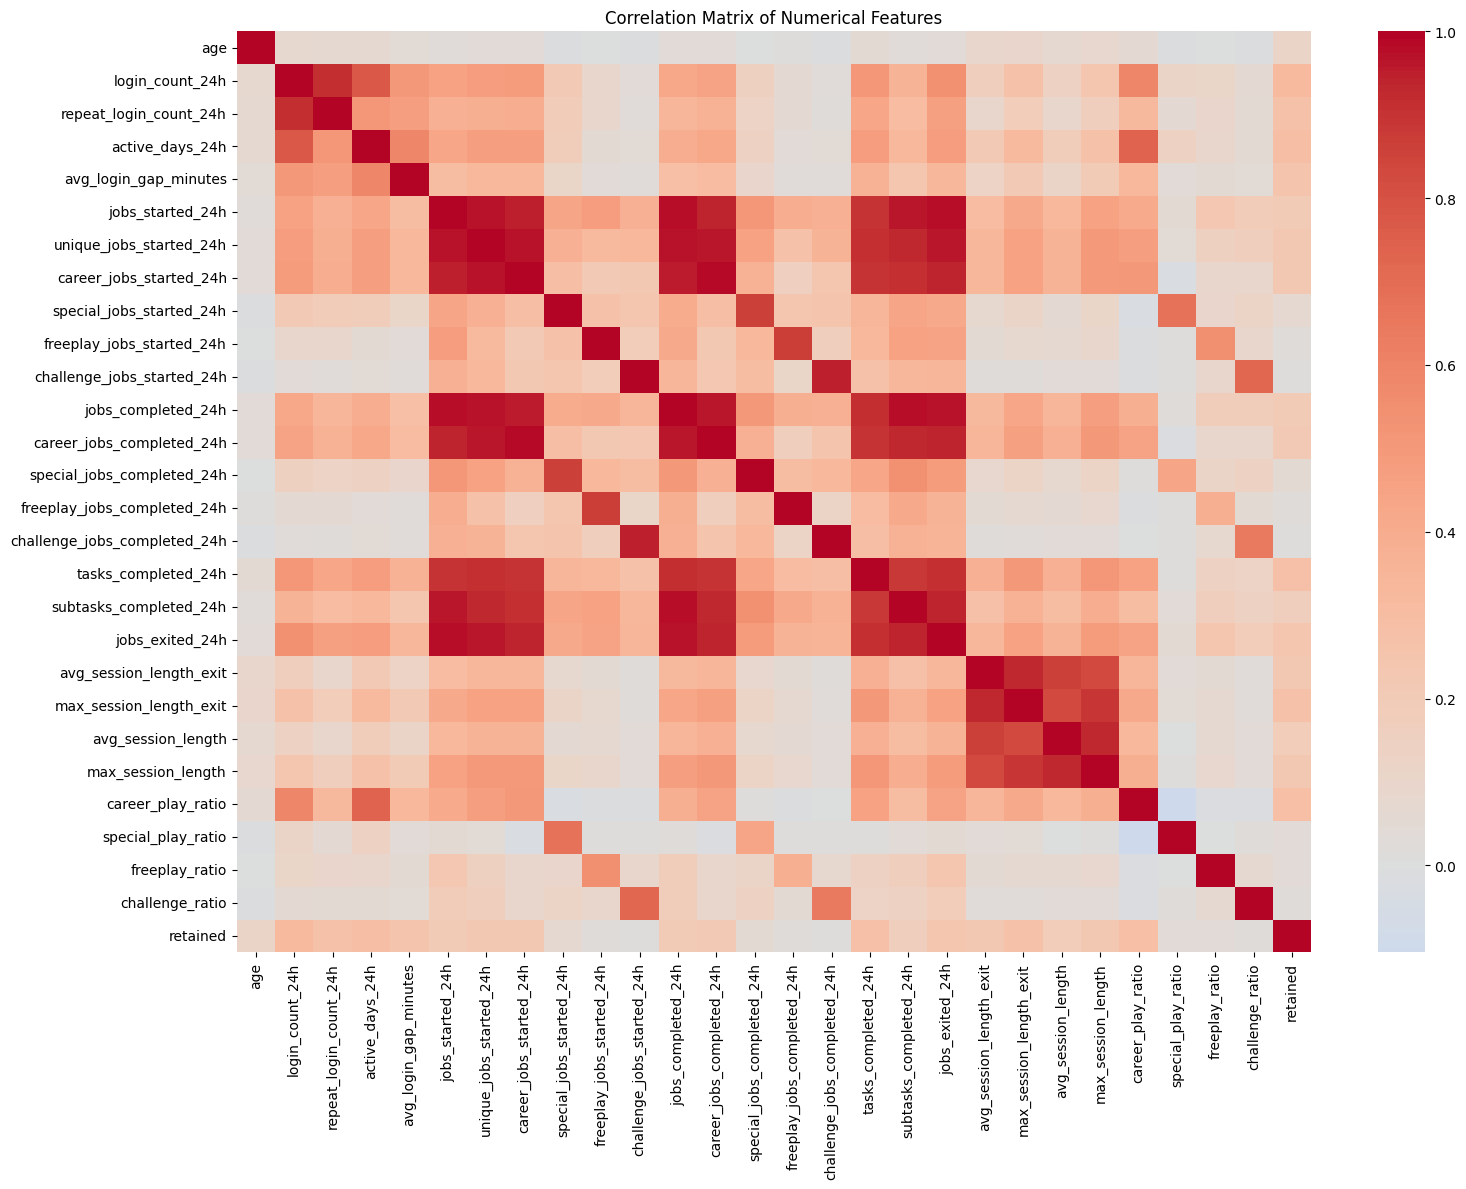

In [32]:
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

In [33]:
# Compute correlation matrix
correlation_matrix = numerical_features.corr().abs()

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Extract highly correlated feature pairs
high_corr = (
    upper_triangle.stack()
    .reset_index()
)

high_corr.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

# Filter correlations >= 0.80
high_corr = (
    high_corr[high_corr["Correlation"] >= 0.90]
    .sort_values(
        by="Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

high_corr

,Feature 1,Feature 2,Correlation
0,career_jobs_started_24h,career_jobs_completed_24h,0.989696
1,jobs_started_24h,jobs_completed_24h,0.981974
2,jobs_started_24h,jobs_exited_24h,0.980550
3,jobs_completed_24h,subtasks_completed_24h,0.977173
4,unique_jobs_started_24h,jobs_completed_24h,0.969838
5,unique_jobs_started_24h,career_jobs_started_24h,0.969827
6,jobs_completed_24h,jobs_exited_24h,0.967275
7,jobs_started_24h,unique_jobs_started_24h,0.967052
8,jobs_completed_24h,career_jobs_completed_24h,0.964201
9,jobs_started_24h,subtasks_completed_24h,0.961919


Correlation analysis was performed as part of the feature engineering validation process. Duplicate engineered features identified through perfect correlations were consolidated at the feature engineering stage. The remaining strong correlations represent naturally related gameplay behaviours rather than duplicated measurements and were therefore retained for predictive modelling.

In [34]:
# Define feature matrix and target variable

X = df.drop(columns=["pid", "retained"])

y = df["retained"]

print(f"Number of Features: {X.shape[1]}")
print(f"Number of Samples : {X.shape[0]}")

X.head()

Number of Features: 29
Number of Samples : 11080


,age,gender,country,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,career_jobs_started_24h,...,subtasks_completed_24h,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio
0,29.0,Male,USA,0,0,0,0.0,0,0,0,...,0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
1,35.0,Male,USA,0,0,0,0.0,0,0,0,...,0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
2,18.0,Male,USA,0,0,0,0.0,0,0,0,...,0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
3,24.0,Female,USA,0,0,0,0.0,0,0,0,...,0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
4,32.0,Female,UK,1,0,1,0.0,1,1,1,...,73,2,106.5,155,58.0,58,1.0,0.0,0.0,0.0


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 8864
Testing Samples  : 2216


In [36]:
train_distribution = (
    y_train.value_counts(normalize=True)
    .rename("Train")
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .rename("Test")
)

distribution = pd.concat(
    [train_distribution, test_distribution],
    axis=1
)

distribution

,Train,Test
retained,,
1,0.502708,0.502708
0,0.497292,0.497292


## Logistic Regression Pipeline

Logistic Regression is used as the baseline classification model for predicting early player retention.

A machine learning pipeline is constructed to ensure that all preprocessing operations are performed consistently during both training and prediction. The pipeline automatically applies:

- Standardization to numerical features
- One-Hot Encoding to categorical features

before fitting the Logistic Regression classifier.

Using a pipeline prevents data leakage, improves reproducibility, and ensures identical preprocessing for future unseen player data.

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.linear_model import LogisticRegression

In [54]:
# Count missing values in each feature

missing_values = (
    X.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

country    410
age        116
gender      62
dtype: int64

In [56]:
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [57]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [50]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print()

print("Categorical Features:")
print(categorical_features)

Numerical Features:
['age', 'login_count_24h', 'repeat_login_count_24h', 'active_days_24h', 'avg_login_gap_minutes', 'jobs_started_24h', 'unique_jobs_started_24h', 'career_jobs_started_24h', 'special_jobs_started_24h', 'freeplay_jobs_started_24h', 'challenge_jobs_started_24h', 'jobs_completed_24h', 'career_jobs_completed_24h', 'special_jobs_completed_24h', 'freeplay_jobs_completed_24h', 'challenge_jobs_completed_24h', 'tasks_completed_24h', 'subtasks_completed_24h', 'jobs_exited_24h', 'avg_session_length_exit', 'max_session_length_exit', 'avg_session_length', 'max_session_length', 'career_play_ratio', 'special_play_ratio', 'freeplay_ratio', 'challenge_ratio']

Categorical Features:
['gender', 'country']


In [58]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [59]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

In [60]:
# Train Logistic Regression Pipeline

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression pipeline trained successfully.")

Logistic Regression pipeline trained successfully.


In [61]:
# Predictions

y_pred_lr = logistic_pipeline.predict(X_test)

y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

## Logistic Regression Evaluation

The trained Logistic Regression model is evaluated using multiple classification metrics to assess its ability to predict early player retention.

The evaluation includes:

- Confusion Matrix
- Classification Report
- Accuracy
- Precision
- Recall
- F1-score
- ROC Curve
- ROC-AUC Score

Using multiple metrics provides a comprehensive assessment of predictive performance and avoids relying solely on classification accuracy.

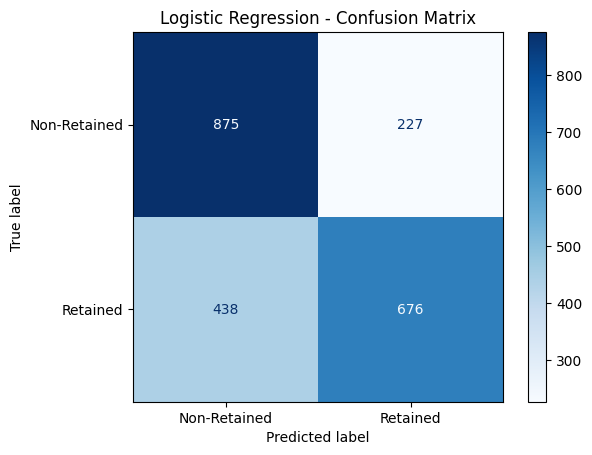

In [64]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Retained", "Retained"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.grid(False)

plt.show()

In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "Non-Retained",
            "Retained"
        ]
    )
)

              precision    recall  f1-score   support

Non-Retained       0.67      0.79      0.72      1102
    Retained       0.75      0.61      0.67      1114

    accuracy                           0.70      2216
   macro avg       0.71      0.70      0.70      2216
weighted avg       0.71      0.70      0.70      2216



In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logistic_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value":[

        accuracy_score(
            y_test,
            y_pred_lr
        ),

        precision_score(
            y_test,
            y_pred_lr
        ),

        recall_score(
            y_test,
            y_pred_lr
        ),

        f1_score(
            y_test,
            y_pred_lr
        ),

        roc_auc_score(
            y_test,
            y_prob_lr
        )

    ]

})

logistic_results["Value"] = logistic_results["Value"].round(4)

logistic_results

,Metric,Value
0,Accuracy,0.6999
1,Precision,0.7486
2,Recall,0.6068
3,F1-score,0.6703
4,ROC-AUC,0.7552


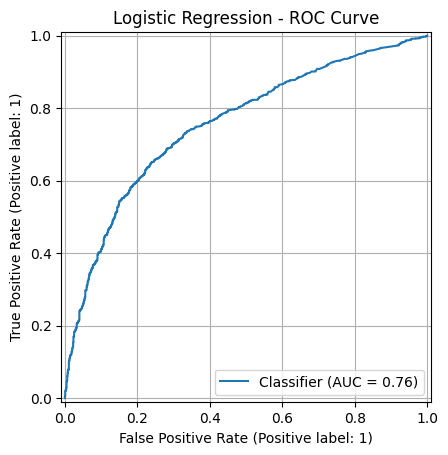

In [67]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("Logistic Regression - ROC Curve")

plt.grid(True)

plt.show()

## Random Forest Pipeline

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions through majority voting.

Unlike Logistic Regression, Random Forest is capable of learning complex non-linear relationships between behavioural features and player retention. It is also naturally robust to multicollinearity and outliers.

The same preprocessing pipeline is retained to ensure a consistent and reproducible modelling workflow.

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [69]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_estimators=100
            )
        )
    ]
)

In [70]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest pipeline trained successfully.")

Random Forest pipeline trained successfully.


In [71]:
y_pred_rf = random_forest_pipeline.predict(X_test)

y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:,1]

In [72]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

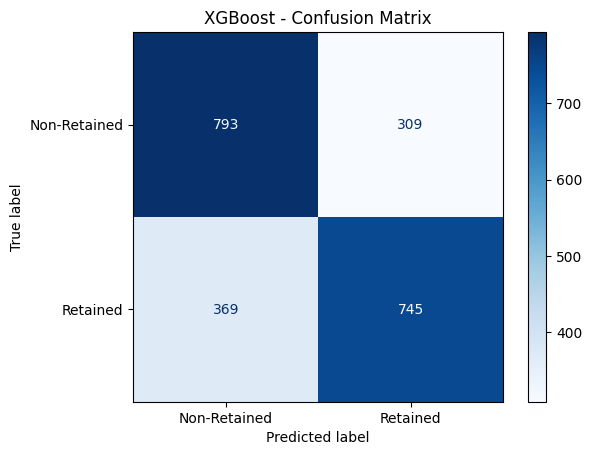

In [87]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Retained", "Retained"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("XGBoost - Confusion Matrix")

plt.grid(False)

plt.show()

In [73]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Non-Retained",
            "Retained"
        ]
    )
)

              precision    recall  f1-score   support

Non-Retained       0.68      0.72      0.70      1102
    Retained       0.71      0.67      0.69      1114

    accuracy                           0.69      2216
   macro avg       0.69      0.69      0.69      2216
weighted avg       0.69      0.69      0.69      2216



In [74]:
random_forest_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value":[

        accuracy_score(
            y_test,
            y_pred_rf
        ),

        precision_score(
            y_test,
            y_pred_rf
        ),

        recall_score(
            y_test,
            y_pred_rf
        ),

        f1_score(
            y_test,
            y_pred_rf
        ),

        roc_auc_score(
            y_test,
            y_prob_rf
        )

    ]

})

random_forest_results["Value"] = random_forest_results["Value"].round(4)

random_forest_results

,Metric,Value
0,Accuracy,0.6940
1,Precision,0.7068
2,Recall,0.6688
3,F1-score,0.6873
4,ROC-AUC,0.7406


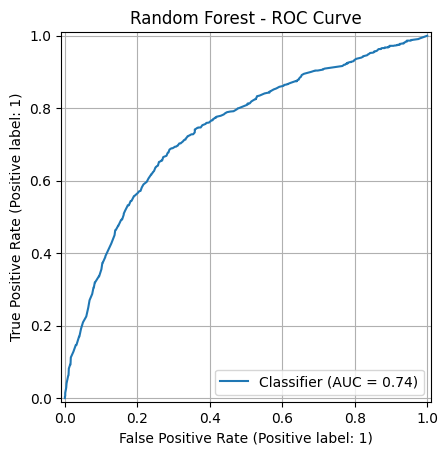

In [75]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest - ROC Curve")

plt.grid(True)

plt.show()

## XGBOOST

In [82]:
from xgboost import XGBClassifier

In [83]:
xgboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [84]:
# Train XGBoost Pipeline

xgboost_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost pipeline trained successfully.")

XGBoost pipeline trained successfully.


In [85]:
# Predict on test dataset

y_pred_xgb = xgboost_pipeline.predict(X_test)

y_prob_xgb = xgboost_pipeline.predict_proba(X_test)[:, 1]

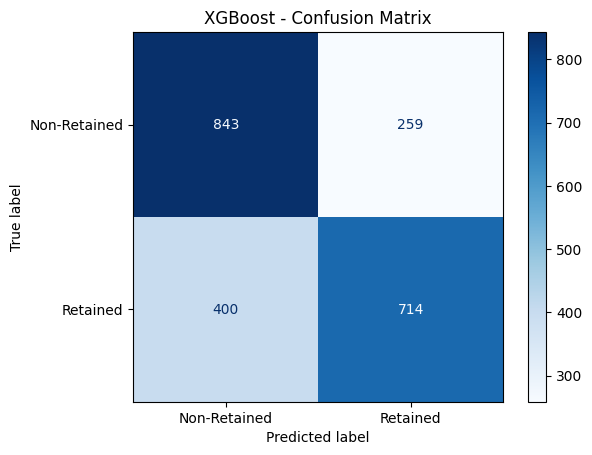

In [86]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Non-Retained", "Retained"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("XGBoost - Confusion Matrix")

plt.grid(False)

plt.show()

In [88]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "Non-Retained",
            "Retained"
        ]
    )
)

              precision    recall  f1-score   support

Non-Retained       0.68      0.76      0.72      1102
    Retained       0.73      0.64      0.68      1114

    accuracy                           0.70      2216
   macro avg       0.71      0.70      0.70      2216
weighted avg       0.71      0.70      0.70      2216



In [89]:
xgboost_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value":[

        accuracy_score(
            y_test,
            y_pred_xgb
        ),

        precision_score(
            y_test,
            y_pred_xgb
        ),

        recall_score(
            y_test,
            y_pred_xgb
        ),

        f1_score(
            y_test,
            y_pred_xgb
        ),

        roc_auc_score(
            y_test,
            y_prob_xgb
        )

    ]

})

xgboost_results["Value"] = xgboost_results["Value"].round(4)

xgboost_results

,Metric,Value
0,Accuracy,0.7026
1,Precision,0.7338
2,Recall,0.6409
3,F1-score,0.6842
4,ROC-AUC,0.7466


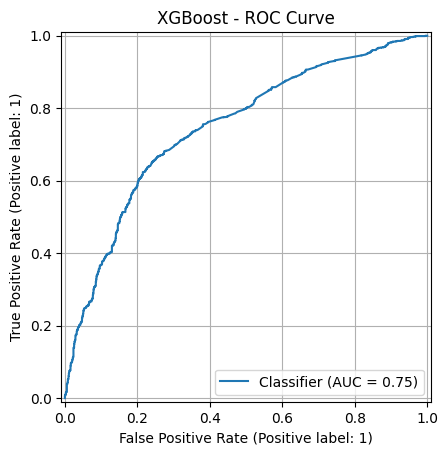

In [90]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("XGBoost - ROC Curve")

plt.grid(True)

plt.show()

### Comparing models

In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model_name, y_true, y_pred, y_prob):

    results = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)],
        "ROC-AUC": [roc_auc_score(y_true, y_prob)]
    })

    return results.round(4)

In [92]:
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

In [93]:
model_comparison = pd.concat(
    [
        lr_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6999,0.7486,0.6068,0.6703,0.7552
1,Random Forest,0.6940,0.7068,0.6688,0.6873,0.7406
2,XGBoost,0.7026,0.7338,0.6409,0.6842,0.7466


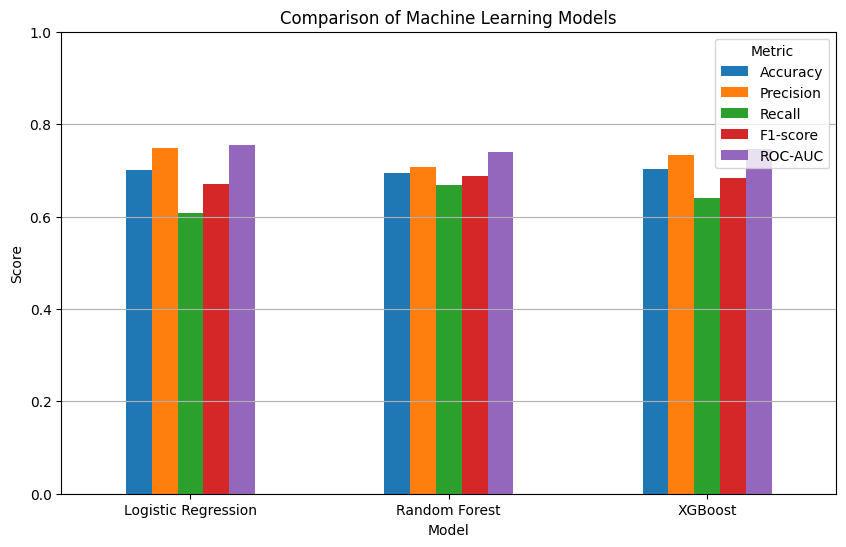

In [94]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

comparison_plot = model_comparison.set_index("Model")[metrics]

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.legend(title="Metric")

plt.show()

### Production approach

In [97]:
import joblib

joblib.dump(logistic_pipeline, "logistic_pipeline.pkl")

['logistic_pipeline.pkl']